# EDA — urgência sintética, Fase 3

## tl;dr

**Demonstração acadêmica, não validação clínica.** O corpus sugerido não possui urgência. Com autorização do responsável, criamos 75 cenários fictícios nos seus cinco temas, com os rótulos pedagógicos `normal`, `atenção` e `urgente`. Não convertemos doença em urgência nem copiamos abstracts para o treino.

A expansão produz 2.700 linhas de treino e 600 de teste, mas apenas **45 + 30 cenários distintos**. Não são 3.300 amostras clínicas independentes. Não há cenários ou textos normalizados compartilhados entre as partições. O teste reservado apresentou 22/30 cenários corretos, macro-F1 0,738; três cenários urgentes foram classificados como atenção. O desempenho não autoriza triagem de pacientes.

## Contexto e métodos

Leitor: autor e avaliadores do Tech Challenge. Decisão: verificar a adaptação de alvo e os limites antes da entrega técnica. Esta análise substitui a EDA operacional anterior de cinco doenças, preservada no histórico Git.

### Premissas

- Fonte temática: [Medical Abstracts TC Corpus](https://github.com/sebischair/Medical-Abstracts-TC-Corpus). Os CSVs originais em `data/raw` não foram alterados.
- Fonte efetiva: `src/techchallenge_fase3/synthetic_cases.py` e gerador `pipelines/generate.py`; não houve anotação clínica especializada.
- Cada tema tem cinco achados por urgência. Seed 42 separa três para treino e dois para teste **antes** da expansão. Prefixos e sufixos neutros são comuns às classes, não regras de urgência.
- 60 variações por cenário de treino; 20 por cenário de teste. Isso atende uma contagem de linhas, não diversidade clínica. A aceitação dessa adaptação cabe à avaliação acadêmica.
- Validação: primeiro fold do StratifiedGroupKFold(5), por `scenario_id`; não são cinco treinos de validação cruzada. Pipeline fixo, sem ajuste pelo teste.
- TF-IDF unigramas + regressão logística balanceada. Somente `report_text` entra no modelo; IDs, tema e origem não são features. Tokenização ASCII é compartilhada com ONNX; termos acentuados são fragmentados. Negações e relações clínicas não são compreendidas semanticamente.

Reprodução: `make generate`, `make eda`, `make notebook`. Kernel limpo, seed fixa, hashes e versões registrados abaixo. As métricas são recalculadas, não apenas lidas de relatórios antigos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from techchallenge_fase3.analysis import describe_corpus
from techchallenge_fase3.config import Settings
from techchallenge_fase3.data import LABEL_NAMES, load_dataset, validate_splits
from techchallenge_fase3.modeling import (
    evaluate_model,
    scenario_evaluation,
    train_model,
    validate_baseline,
)
from techchallenge_fase3.reporting import environment, file_hash

settings = Settings()
train = load_dataset(settings.train_path)
test = load_dataset(settings.test_path)
validate_splits(train, test)
eda = describe_corpus(train, test)
names = list(LABEL_NAMES.values())
colors = ["#227C9D", "#D99B23", "#B44747"]
figure_dir = Path("reports/figures")
figure_dir.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", 80)
plt.rcParams.update(
    {
        "figure.figsize": (9, 4.5),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def save_figure(name):
    plt.tight_layout()
    plt.savefig(figure_dir / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

## Dados

### Proveniência e contrato

Grão de cada linha: uma redação de um cenário fictício. `scenario_id` identifica sua família; `urgency_label` é o alvo pedagógico. Não há pacientes, hospitais, datas de eventos, dados demográficos ou desfechos reais. Datas de execução medem apenas a produção do artefato.

In [2]:
display(
    pd.DataFrame(
        [
            {"arquivo": p.as_posix(), "sha256": file_hash(p)}
            for p in (settings.train_path, settings.test_path, settings.labels_path)
        ]
    )
)
display(
    pd.DataFrame(
        [
            {
                "partição": name,
                "linhas": eda[name]["rows"],
                "cenários": eda["scenarios"][name],
                "nulos": sum(eda[name]["nulls"].values()),
                "textos repetidos": eda[name]["duplicate_text_rows_beyond_first"],
                "conflitos de rótulo": eda[name]["conflicting_text_groups"],
                "fora do limite API": eda[name]["outside_api_length"],
            }
            for name in ("train", "test")
        ]
    )
)
assert eda["scenarios"]["shared"] == 0
assert eda["overlap"]["shared_text_groups"] == 0
assert len(train) == 2700 and len(test) == 600
display(
    Markdown(
        "**Integridade:** nenhuma ausência, conflito ou violação do limite textual foi observada. Isso valida o gerador, não a representatividade clínica."
    )
)

,arquivo,sha256
0,data/synthetic_triage/synthetic_triage_train.csv,7482700fe0c5ffafd2902aea557704c7c5718cea979f19ff934d88a95576cad9
1,data/synthetic_triage/synthetic_triage_test.csv,18ebf65a7535fa0a3588ded2a8bb289ccdb3603c0a3226ecc2d38a8e6caaec1d
2,data/synthetic_triage/synthetic_triage_labels.csv,353a4b7e28000a11494d3cd4fc6b7755b4ecc3ff96583ceea5d962bcaba217ae


,partição,linhas,cenários,nulos,textos repetidos,conflitos de rótulo,fora do limite API
0,train,2700,45,0,0,0,0
1,test,600,30,0,0,0,0


**Integridade:** nenhuma ausência, conflito ou violação do limite textual foi observada. Isso valida o gerador, não a representatividade clínica.

### Classes: equilíbrio imposto pelo desenho, não prevalência hospitalar

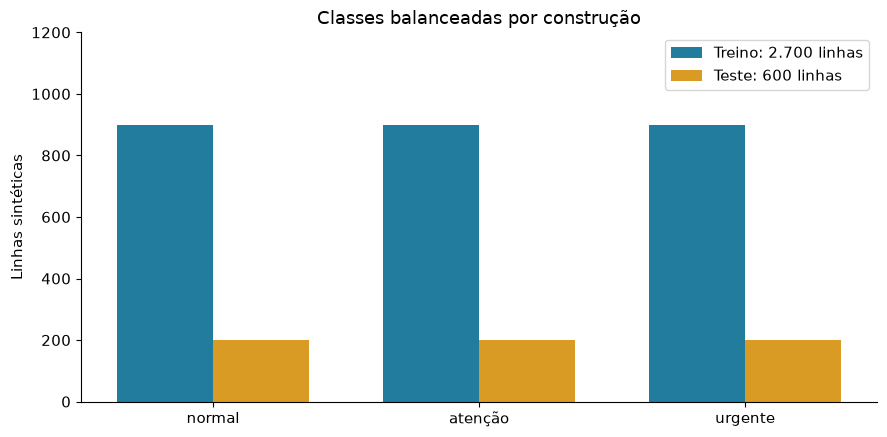

,name,train,test,train_share,test_share
0,normal,900,200,0.333,0.333
1,atenção,900,200,0.333,0.333
2,urgente,900,200,0.333,0.333


In [3]:
classes = pd.DataFrame(eda["classes"])
fig, ax = plt.subplots()
x = np.arange(3)
ax.bar(x - 0.18, classes.train, 0.36, label="Treino: 2.700 linhas", color="#227C9D")
ax.bar(x + 0.18, classes.test, 0.36, label="Teste: 600 linhas", color="#D99B23")
ax.set(
    xticks=x,
    xticklabels=names,
    ylabel="Linhas sintéticas",
    ylim=(0, 1200),
    title="Classes balanceadas por construção",
)
ax.legend()
save_figure("class_distribution")
display(classes[["name", "train", "test", "train_share", "test_share"]].round(3))

### Variações não aumentam o número de cenários independentes

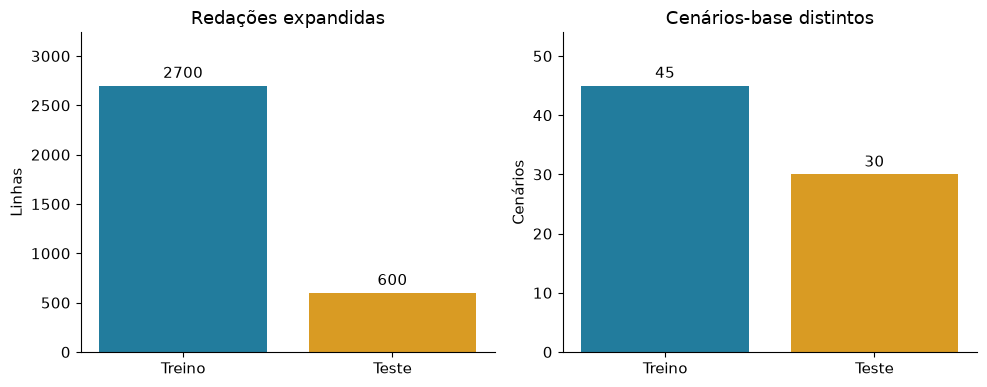

As 60/20 redações de cada cenário compartilham o mesmo achado. O suporte efetivo é pequeno; não calculamos intervalos de confiança tratando variações como observações independentes.

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, title, unit in zip(
    axes,
    (
        [len(train), len(test)],
        [train.scenario_id.nunique(), test.scenario_id.nunique()],
    ),
    ("Redações expandidas", "Cenários-base distintos"),
    ("Linhas", "Cenários"),
    strict=True,
):
    bars = ax.bar(["Treino", "Teste"], values, color=["#227C9D", "#D99B23"])
    ax.bar_label(bars, padding=3)
    ax.set(title=title, ylabel=unit, ylim=(0, max(values) * 1.2))
save_figure("scenario_support")
display(
    Markdown(
        "As 60/20 redações de cada cenário compartilham o mesmo achado. O suporte efetivo é pequeno; não calculamos intervalos de confiança tratando variações como observações independentes."
    )
)

### Comprimentos: contrato da API e custo de inferência

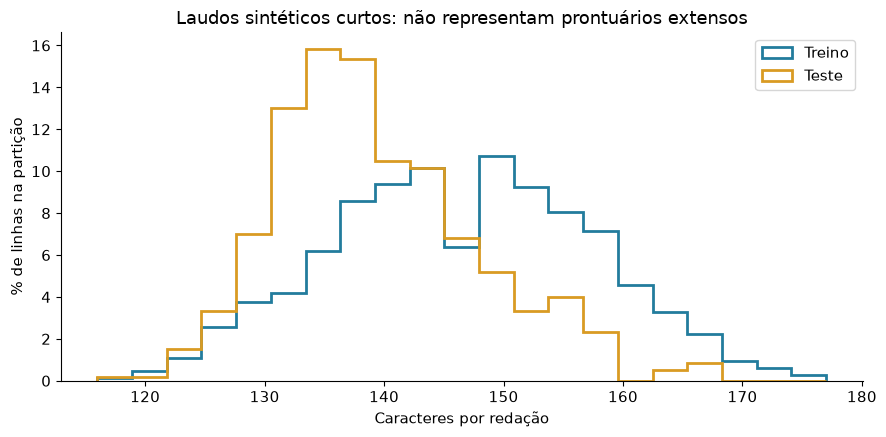

,train,test
count,2700.0,600.0
mean,146.5,139.5
std,10.9,8.5
min,116.0,118.0
1%,123.0,123.0
5%,128.0,127.0
50%,147.0,138.0
95%,165.0,155.0
99%,171.0,165.0
max,177.0,168.0


In [5]:
fig, ax = plt.subplots()
bins = np.linspace(
    min(train.report_text.str.len().min(), test.report_text.str.len().min()),
    max(train.report_text.str.len().max(), test.report_text.str.len().max()),
    22,
)
for data, color, name in ((train, "#227C9D", "Treino"), (test, "#D99B23", "Teste")):
    values = data.report_text.str.len()
    ax.hist(
        values,
        bins=bins,
        weights=np.ones(len(values)) / len(values) * 100,
        histtype="step",
        linewidth=2,
        label=name,
        color=color,
    )
ax.set(
    xlabel="Caracteres por redação",
    ylabel="% de linhas na partição",
    title="Laudos sintéticos curtos: não representam prontuários extensos",
)
ax.legend()
save_figure("text_lengths")
display(
    pd.DataFrame({name: eda[name]["characters"] for name in ("train", "test")}).round(1)
)

### Extensão por classe e possíveis atalhos do gerador

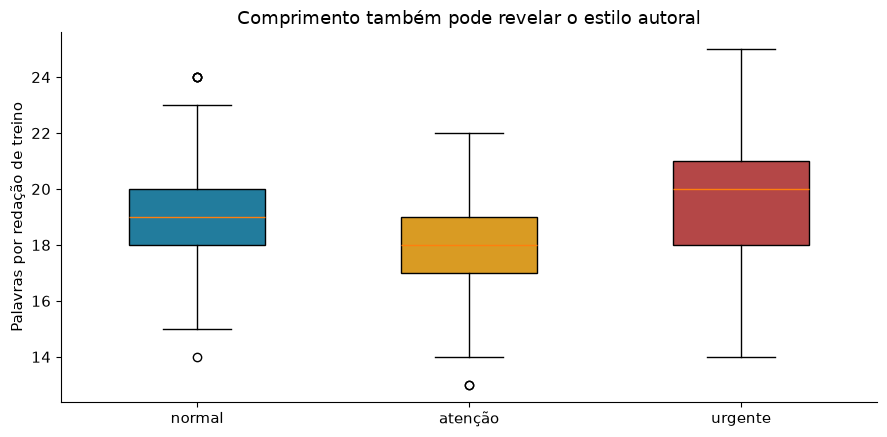

,normal,atenção,urgente
0,de,sem,com
1,sem,estável,da
2,exame,do,do
3,ou,exame,de
4,do,achados,queda
5,estudo,espessamento,exame
6,avaliação,descrição,achados
7,não,de,compressão
8,alteração,ou,extensa
9,achados,avaliação,volumoso


Palavras como “sem”, “estável” ou termos de comprometimento podem servir de atalhos. O modelo aprende associações do autor; essa separabilidade não demonstra raciocínio clínico.

In [6]:
fig, ax = plt.subplots()
for index, label in enumerate(LABEL_NAMES):
    words = (
        train.loc[train.urgency_label.eq(label), "report_text"].str.split().str.len()
    )
    ax.boxplot(
        words,
        positions=[index],
        widths=0.5,
        tick_labels=[names[index]],
        patch_artist=True,
        boxprops={"facecolor": colors[index]},
    )
ax.set(
    xticks=range(3),
    xticklabels=names,
    ylabel="Palavras por redação de treino",
    title="Comprimento também pode revelar o estilo autoral",
)
save_figure("words_by_class")
display(
    pd.DataFrame(eda["lexical"]["top_mean_tfidf_terms_by_class"]).rename(
        columns={str(k): v for k, v in LABEL_NAMES.items()}
    )
)
display(
    Markdown(
        "Palavras como “sem”, “estável” ou termos de comprometimento podem servir de atalhos. O modelo aprende associações do autor; essa separabilidade não demonstra raciocínio clínico."
    )
)

### Sobreposição e cobertura lexical

Zero overlap exato não elimina semelhança de estilo. A similaridade usa vocabulário ajustado somente no treino. O teste compartilha prefixos e sufixos neutros; OOV e similaridade são diagnósticos lexicais, não validação externa.

,vocabulário EDA,tokens OOV no teste (%),vetores zerados,textos compartilhados,cenários compartilhados
0,233,14.808,0,0,0


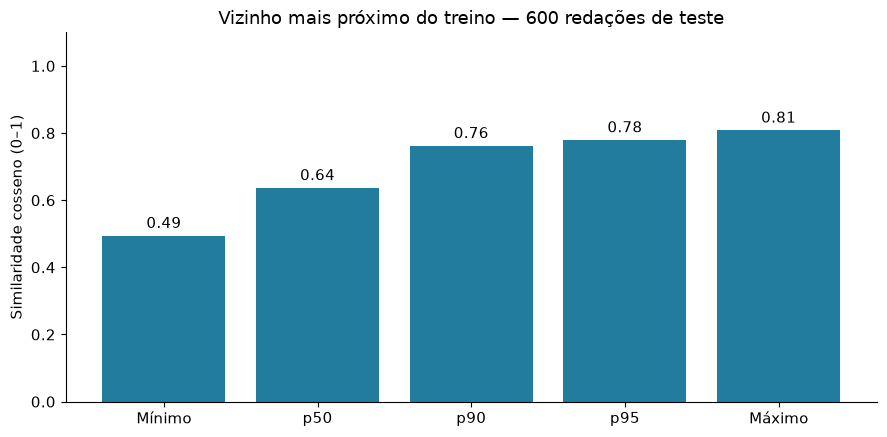

{'character_length_ks_statistic': 0.30907407407407406,
 'character_length_ks_pvalue': 5.465643990489445e-42,
 'caveat': 'Variações de cenários violam independência; KS apenas exploratório.',
 'temporal_analysis': 'Sem datas, pacientes, hospitais ou origem por linha.'}

In [7]:
lexical = eda["lexical"]
display(
    pd.DataFrame(
        [
            {
                "vocabulário EDA": lexical["vocabulary_size"],
                "tokens OOV no teste (%)": lexical["test_oov_token_share"] * 100,
                "vetores zerados": lexical["test_zero_vectors"],
                "textos compartilhados": eda["overlap"]["shared_text_groups"],
                "cenários compartilhados": eda["scenarios"]["shared"],
            }
        ]
    ).round(3)
)
quantiles = lexical["near_duplicates"]["unseen_test_similarity_quantiles"]
fig, ax = plt.subplots()
bars = ax.bar(["Mínimo", "p50", "p90", "p95", "Máximo"], quantiles, color="#227C9D")
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set(
    ylim=(0, 1.1),
    ylabel="Similaridade cosseno (0–1)",
    title="Vizinho mais próximo do treino — 600 redações de teste",
)
save_figure("lexical_similarity")
display(eda["distribution"])

## Resultados

### Baseline, validação por cenário e teste reservado

Modelo fixo, sem busca de hiperparâmetros. A classe majoritária é a referência mínima. Avaliamos também uma primeira redação fixa de cada cenário de teste, sem votação entre variantes. O teste não foi usado para modificar os achados ou otimizar o modelo.

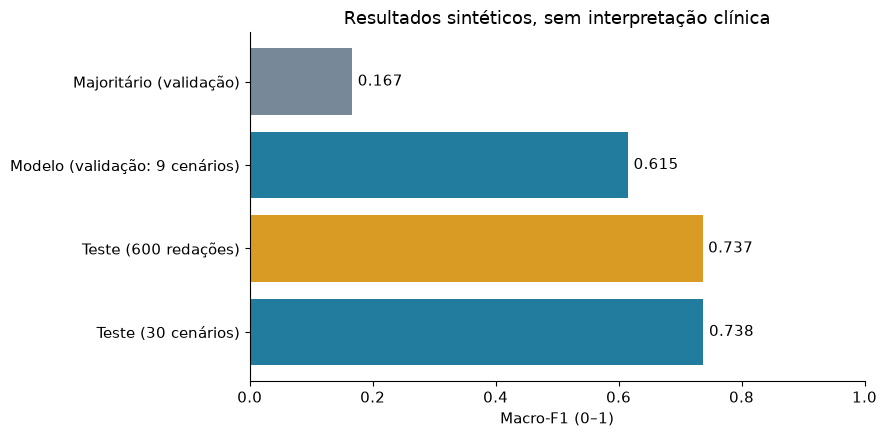

,precision,recall,f1-score,support
normal,0.800,0.8,0.800,10.0
atenção,0.583,0.7,0.636,10.0
urgente,0.875,0.7,0.778,10.0


In [8]:
validation = validate_baseline(train)
model = train_model(train)
test_metrics = evaluate_model(model, test)
scenario_metrics = scenario_evaluation(model, test)
scores = [
    validation["majority_baseline"]["macro_f1"],
    validation["model"]["macro_f1"],
    test_metrics["macro_f1"],
    scenario_metrics["metrics"]["macro_f1"],
]
fig, ax = plt.subplots()
bars = ax.barh(
    [
        "Majoritário (validação)",
        "Modelo (validação: 9 cenários)",
        "Teste (600 redações)",
        "Teste (30 cenários)",
    ],
    scores,
    color=["#778899", "#227C9D", "#D99B23", "#227C9D"],
)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set(
    xlim=(0, 1),
    xlabel="Macro-F1 (0–1)",
    title="Resultados sintéticos, sem interpretação clínica",
)
ax.invert_yaxis()
save_figure("model_performance")
display(
    pd.DataFrame(scenario_metrics["metrics"]["per_class"])
    .T.rename(index={str(k): v for k, v in LABEL_NAMES.items()})
    .round(3)
)
assert set(model.classes_) == {0, 1, 2}

### Matriz de confusão: os erros são parte da entrega

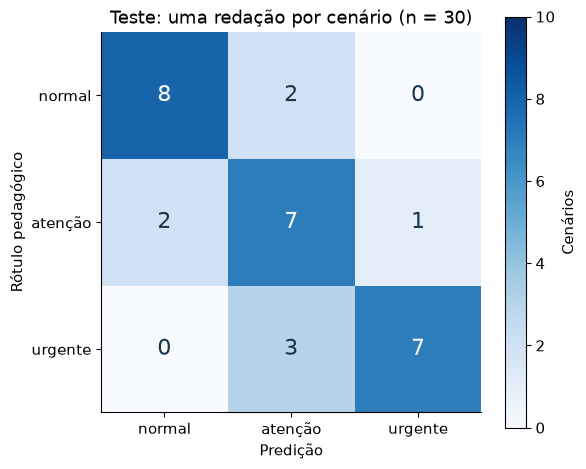

,scenario_id,urgency_label,predicted_label
0,neoplasms-0-0,0,1
1,neoplasms-1-4,1,2
2,neoplasms-1-1,1,0
3,digestive-0-0,0,1
4,digestive-2-4,2,1
5,neurologic-2-2,2,1
6,cardiovascular-1-4,1,0
7,general-2-1,2,1


**8/30 cenários incorretos**, 5 subestimados e 3 superestimados. Urgente → atenção: 3; urgente → normal: 0. Zero nessa última célula não comprova segurança.

In [9]:
matrix = np.asarray(scenario_metrics["metrics"]["confusion_matrix"])
assert matrix.sum() == 30
fig, ax = plt.subplots(figsize=(6, 5))
heatmap = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=10)
for row in range(3):
    for col in range(3):
        ax.text(
            col,
            row,
            str(matrix[row, col]),
            ha="center",
            va="center",
            color="white" if matrix[row, col] > 5 else "#17324D",
            fontsize=16,
        )
ax.set(
    xticks=range(3),
    yticks=range(3),
    xticklabels=names,
    yticklabels=names,
    xlabel="Predição",
    ylabel="Rótulo pedagógico",
    title="Teste: uma redação por cenário (n = 30)",
)
fig.colorbar(heatmap, ax=ax, label="Cenários")
save_figure("confusion_scenarios")
errors = pd.DataFrame(scenario_metrics["errors"])
display(errors)
display(
    Markdown(
        f"**{len(errors)}/30 cenários incorretos**, {scenario_metrics['underassigned']} subestimados e {scenario_metrics['overassigned']} superestimados. Urgente → atenção: {matrix[2, 1]}; urgente → normal: {matrix[2, 0]}. Zero nessa última célula não comprova segurança."
    )
)

## Conclusões

1. **Alvo corrigido:** três urgências, não cinco doenças. Proveniência sintética acompanha os dados, o modelo e cada resposta da API. Nenhum mapeamento doença → urgência é aplicado.
2. **Diversidade é o gargalo:** 75 cenários autorais e redações repetidas sustentam apenas uma demonstração de engenharia. Mais de 2.000 linhas não equivalem a 2.000 casos independentes. Confirmar a adaptação com a avaliação acadêmica.
3. **Avaliação sem vazamento de família:** 36/9 cenários no holdout e 45/30 no treino/teste final. Compartilhamento de estilo permanece; não há validade externa.
4. **Desempenho limitado:** macro-F1 de validação 0,615 versus 0,167 do majoritário; teste por cenário 0,738. Oito erros em 30 cenários, incluindo três urgentes subestimados. A API não pode ser usada para decisões clínicas.
5. **Engenharia verificável:** contrato valida origem, três classes e isolamento; exportação ONNX só é aprovada após equivalência de rótulos/probabilidades e ganho de latência medido. O monitoramento mede serviço, não qualidade clínica.
6. **Evolução responsável:** uma aplicação real exigiria dados de laudos com urgência anotada por especialistas, acesso autorizado, validação externa e temporal, estudo de negações e calibração. Esses itens não foram realizados.

### Verificação

Notebook executado de cima para baixo. Contagens, partições e matriz reconciliadas. Sete figuras calculadas a partir dos CSVs gerados; sem pacientes reais. Ambiente abaixo. Confiança retornada é a maior probabilidade do modelo, **não calibrada** e não é probabilidade de risco clínico.

In [10]:
display(environment())

{'created_at': '2026-09-16T00:54:04.051625+00:00',
 'python': '3.11.15',
 'platform': 'Windows-10-10.0.26200-SP0',
 'packages': {'scikit-learn': '1.9.0',
  'numpy': '2.4.6',
  'pandas': '2.3.3',
  'onnxruntime': '1.29.0',
  'skl2onnx': '1.20.0'}}